In [1]:
# --- 1. CONFIG AND DEFINITIONS ---

# Dataset and data root config
import random
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

dataset = 'mlc25'
data_root = './data'
use_optuna = False
use_pca = True

seed = random.randint(0, 100000)

In [2]:
import numpy as np

def mean_euclidean_error(y_true, y_pred):
    # Calculate the difference between true and predicted values
    diff = y_true - y_pred
    
    # Reshapes row vectors to column vectors for consistent norm calculation
    if diff.ndim == 1:
        diff = diff.reshape(-1, 1)

    # Calculate mean Euclidean error
    return np.linalg.norm(diff, axis=1).mean()

In [3]:
from sklearn.metrics import make_scorer

# Create a scorer for use in model evaluation
mee_scorer = make_scorer(mean_euclidean_error, greater_is_better=False)

### Data Loading

If you occur in "SyntaxError: f-string: unmatched '(' (keras.py, line 50)" just run again the cell

In [4]:
# === 2. IMPORTS AND UTILITIES ===
from utils.data_loader import get_monk1_data, get_ml_cup_data  
from torch.utils.data import DataLoader, TensorDataset
from models import SVCModel, SVRModel
from sklearn.metrics import *
from sklearn.multioutput import MultiOutputRegressor
  
    
# --- Utility function to extract data from DataLoader to NumPy arrays ---
def extract_data_to_numpy(data_loader):
    """
    Converts data from a PyTorch DataLoader into a flattened NumPy array pair (X, y).
    Targets (y) are returned in their original dimensionality (e.g., [N, M] for multi-output).
    """
    X_list = []
    y_list = []
    for X, y in data_loader:
        # Flatten the input (e.g., 28x28 image -> 784 features)
        X_list.append(X.view(X.size(0), -1).numpy()) 
        # Convert labels to NumPy
        y_list.append(y.numpy())
    
    X_data = np.concatenate(X_list)
    y_data = np.concatenate(y_list)
    
    # We return y_data as is (2D array, e.g., [N, 1] or [N, M]).
    return X_data, y_data

c:\Users\Michael\Desktop\Rage-Against-ML\.venv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):
c:\Users\Michael\Desktop\Rage-Against-ML\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
from sklearn.preprocessing import StandardScaler

# Use StandardScaler for feature scaling with 0 mean and unit variance
scaler = StandardScaler()

In [7]:
# === 3. DATA LOADING AND PREPARATION ===

from utils.data_loader import get_monk1_data, get_ml_cup_data
import sys

dataset_name = dataset
BATCH_SIZE = 1024 

print(f"Loading dataset: {dataset_name.upper()}...")
    
# Determine task type and load data
if dataset_name == 'monk1':
    train_loader, test_loader, INPUT_SIZE, OUTPUT_SIZE = get_monk1_data(BATCH_SIZE, data_root)
    is_regression_task = False
    metric_name = "Test Accuracy (%)"

elif dataset_name == 'mlc25':
    # The new get_ml_cup_data returns 7 values.
    # We set validation_ratio=0.0 to keep all training data in train_loader.
    # The 'mps' argument is removed (handled internally by data_loader).
    train_loader, _, test_loader, _, INPUT_SIZE, OUTPUT_SIZE, _ = get_ml_cup_data(
        BATCH_SIZE, 
        data_root, 
        validation_ratio=0.0,   # No validation split (matches old behavior)
        test_ratio=0.25,        # Matches your snippet
        scaler=scaler,
        scale_target=False      # SVM usually doesn't need target scaling logic from this loader
    )
    is_regression_task = True
    metric_name = "Test MEE"

else:
    raise ValueError("Unsupported dataset for SVM.")


# --- 3.2 Data Preparation for Scikit-learn ---

# Convert DataLoaders (PyTorch) to NumPy arrays (Scikit-learn)
X_train, y_train = extract_data_to_numpy(train_loader)
X_test, y_test = extract_data_to_numpy(test_loader)

print(f"Data loaded: Training samples={X_train.shape[0]}, Test samples={X_test.shape[0]}")

Loading dataset: MLC25...
Parsing ML-CUP data...
Data Split: Train=375, Val=0, Internal Test=125 (Blind Test=1000)
Applying scaling StandardScaler to Inputs...
Data loaded: Training samples=375, Test samples=125


In [8]:
from sklearn.decomposition import PCA
import joblib

# Apply PCA if specified
pca_model = None

if use_pca:
    print("Applying PCA for dimensionality reduction...")
    pca_model = PCA(n_components=2, random_state=seed)  # Retain 2 principal components as suggested 
    print(f"Original feature dimensions: {X_train.shape[1]}")
    
    # Transform the data
    X_train = pca_model.fit_transform(X_train)
    X_test = pca_model.transform(X_test)
    
    print(f"PCA applied: Reduced feature dimensions to {X_train.shape[1]}")
   
else:
    print("PCA not applied.")

Applying PCA for dimensionality reduction...
Original feature dimensions: 12
PCA applied: Reduced feature dimensions to 2


In [9]:
# Verify shapes

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((375, 2), (375, 4), (125, 2), (125, 4))

In [10]:
# Directory setup for saving results and models
import os   
import datetime

base_dir = "./svm_saved_models"
task_subfolder = "regression" if is_regression_task else "classification"
preprocess_subfolder = "PCA" if use_pca else "Standard"
method_subfolder = "Optuna" if use_optuna else "RandomSearch"

timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
model_type = "SVR" if is_regression_task else "SVC"
run_name = f"{model_type}_{timestamp}"

run_dir = os.path.join(base_dir, task_subfolder, preprocess_subfolder, method_subfolder, run_name)
os.makedirs(run_dir, exist_ok=True)


In [12]:
# --- 4. RANDOM SEARCH---

# 4.1 Parameter Definition
if not use_optuna:
    from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, KFold
    from sklearn.svm import SVC, SVR
    from scipy.stats import loguniform, uniform

    # 1. Definition of parameters in common for both SVC and SVR
    common_params = [
        # 1. Linear Kernel: C is the ONLY parameter. Gamma is implicitly 'scale' or ignored.
        {
            'kernel': ['linear'],
            'C': loguniform(1e-3, 1e2),
        },
        
        # 2.A RBF Kernels with Discrete Gamma
        {
            'kernel': ['rbf'],
            'C': loguniform(1e-3, 1e2),
            'gamma': ['scale', 'auto'], # Discrete strings only
        },
        # 2.B RBF Kernels with Continuous Gamma
        {
            'kernel': ['rbf'],
            'C': loguniform(1e-3, 1e2),
            'gamma': loguniform(1e-3, 1e1), # Continuous distribution object only
        },
        # 3.A Poly Kernels with Discrete Gamma
        {
            'kernel': ['poly'],
            'C': loguniform(1e-3, 1e2),
            'gamma': ['scale', 'auto'], # Discrete strings only
            'degree': [2,3,4,5],
            'coef0': uniform(0, 10)
        },
        # 3.B Poly Kernels with Continuous Gamma  
        {
            'kernel': ['poly'],
            'C': loguniform(1e-3, 1e2),
            'gamma': loguniform(1e-3, 1e1), # Continuous distribution object only
            'degree': [2,3,4,5],
            'coef0': uniform(0, 10)
        }
    ]

    # 2. Conditional logic for epsilon parameter in SVR
    if is_regression_task:
        params = []
        for p in common_params:
            p_new = p.copy()
            p_new['epsilon'] = loguniform(1e-2,1e1)
            params.append(p_new)  # Append modified copy for SVR
        
        print("SVR parameters with epsilon added.")

    else:
        params = common_params
        print("SVC parameters without epsilon.")


    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed) if not is_regression_task else KFold(n_splits=5, shuffle=True, random_state=seed)  

SVR parameters with epsilon added.


In [13]:
# 4.2 Randomized Search configuration
if not use_optuna:
    # HP Randomized Search Configuration

    limit = 100000
    size = 1000

    # Max iter and cache size set for efficiency
    base_estimator = SVC(max_iter=limit, cache_size=size) if not is_regression_task \
                else SVR(max_iter=limit, cache_size=size)

    hp_search = RandomizedSearchCV(
        estimator = base_estimator,
        param_distributions = params,
        n_iter = 200,                     # Number of random configurations to try
        scoring = 'accuracy' if not is_regression_task else mee_scorer,
        cv = kfold, 
        n_jobs = -1,
        verbose = 1,
        random_state = seed
     )                          


In [14]:
# 4.3 Model Wrapping (if needed)
if not use_optuna:
    if is_regression_task:
        # Wrap in MultiOutputRegressor if the dataset is mlc25
        final_model = MultiOutputRegressor(hp_search)  
    else:
        final_model = hp_search

In [15]:
# 4.4 Execute Randomized Search and Fit Final Model
if not use_optuna:
    final_model.fit(X_train, y_train)

    best_cv_scores = []

    if is_regression_task:
        for estimator in final_model.estimators_:
            best_cv_scores.append(abs(estimator.best_score_))
    else:
        best_cv_scores.append(final_model.best_score_)

Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Fitting 5 folds for each of 200 candidates, totalling 1000 fits



💾 Saving Random Search Results & Plots...
Processing Target 0...
   -> CSV saved: ./svm_saved_models\regression\PCA\RandomSearch\SVR_20251228_235335\rs_results_target_0.csv


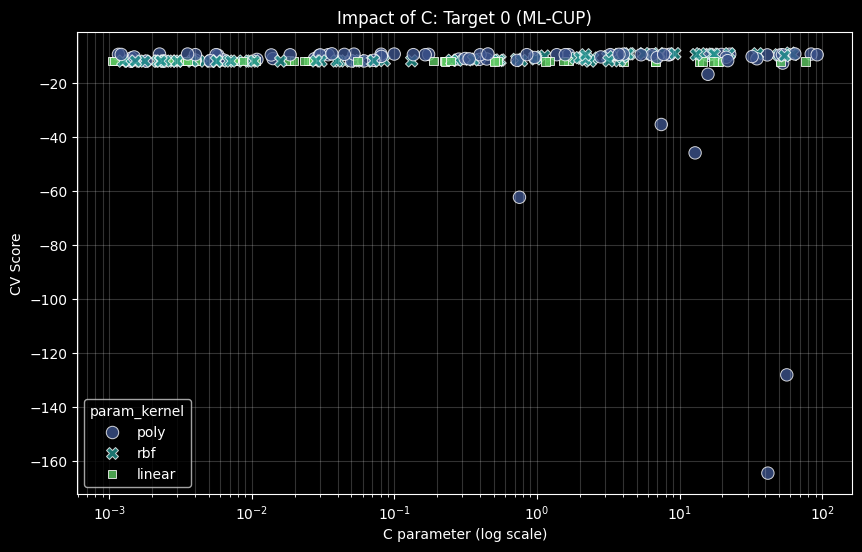

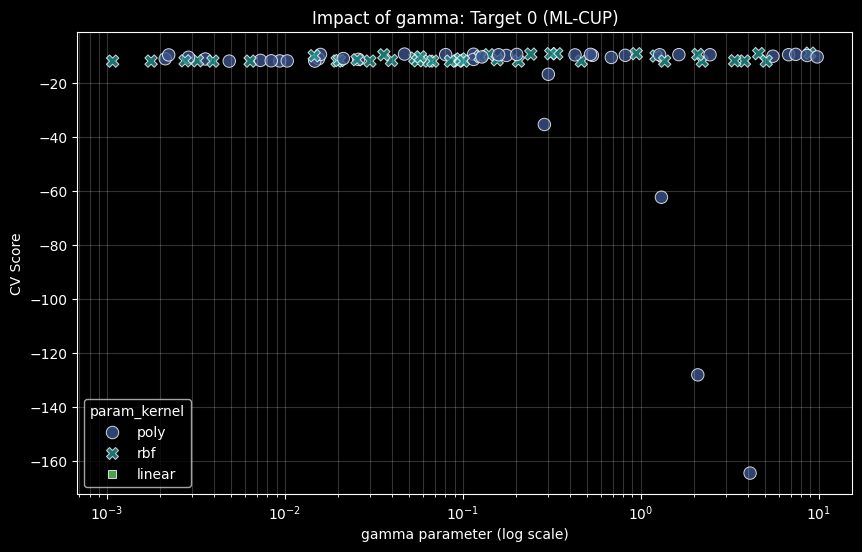

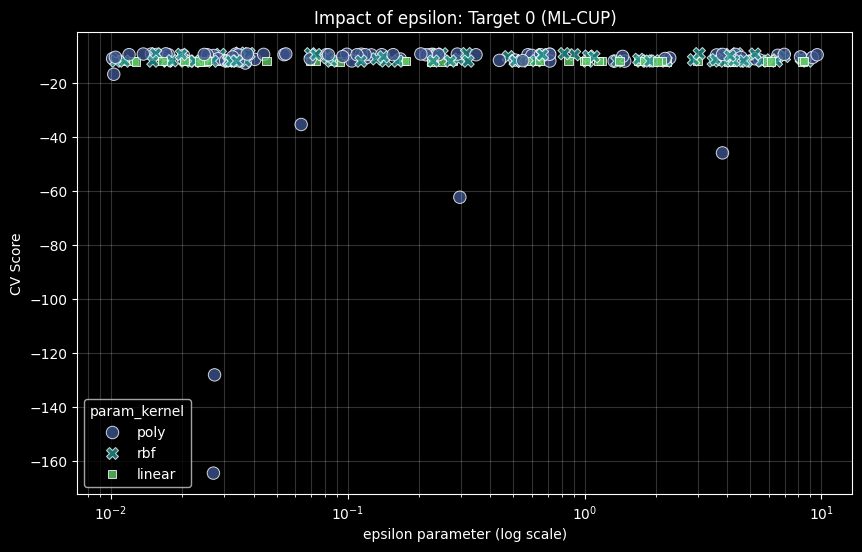

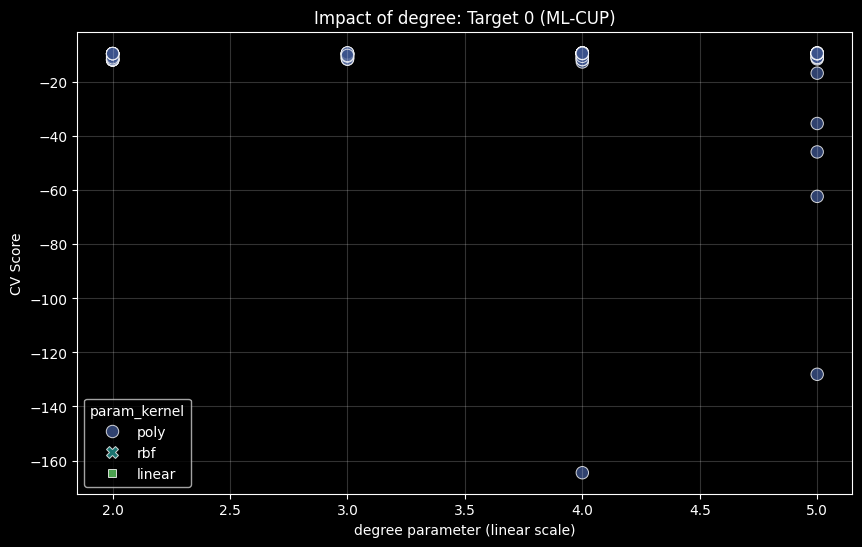

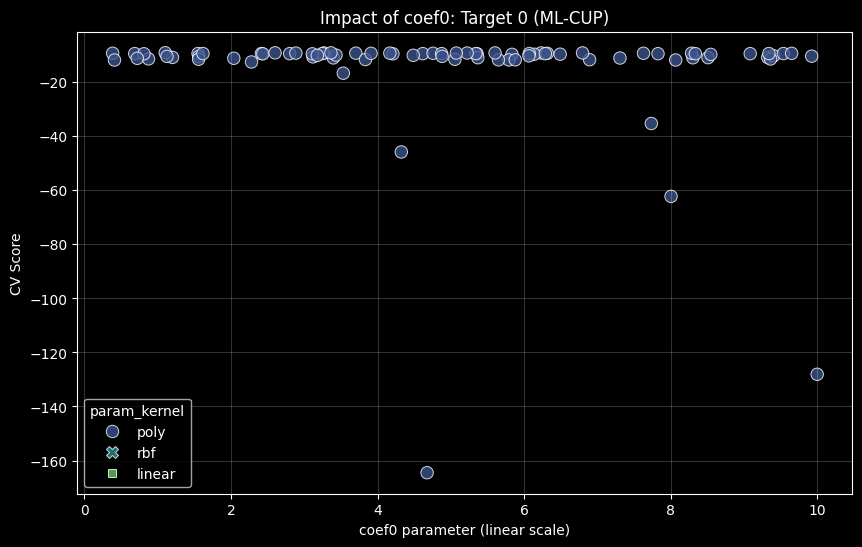

   -> All plots saved in ./svm_saved_models\regression\PCA\RandomSearch\SVR_20251228_235335
Processing Target 1...
   -> CSV saved: ./svm_saved_models\regression\PCA\RandomSearch\SVR_20251228_235335\rs_results_target_1.csv


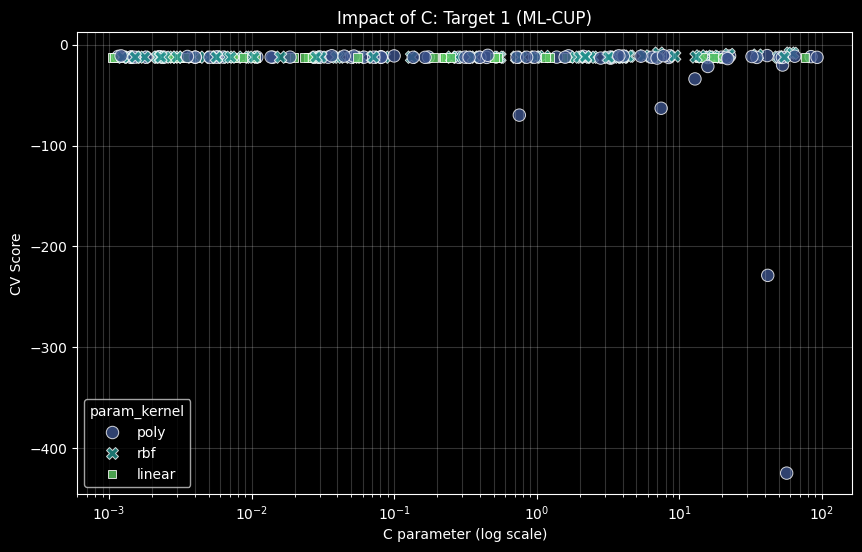

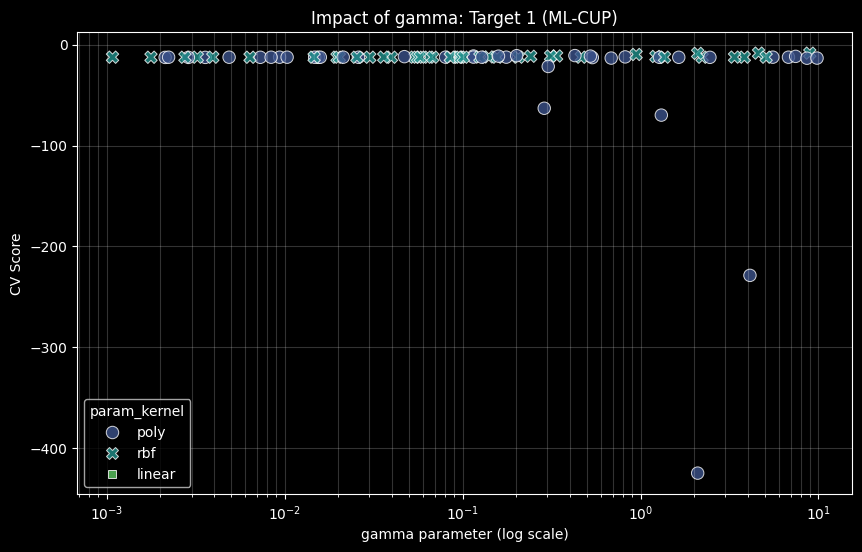

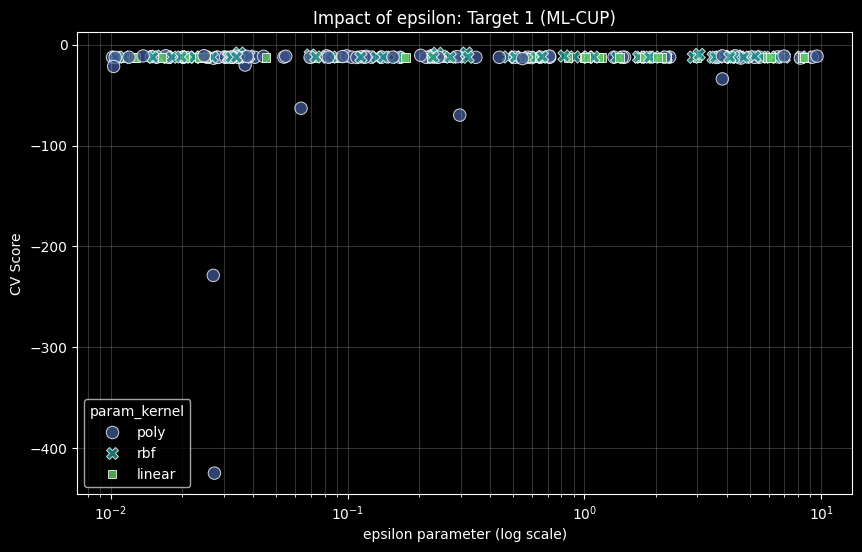

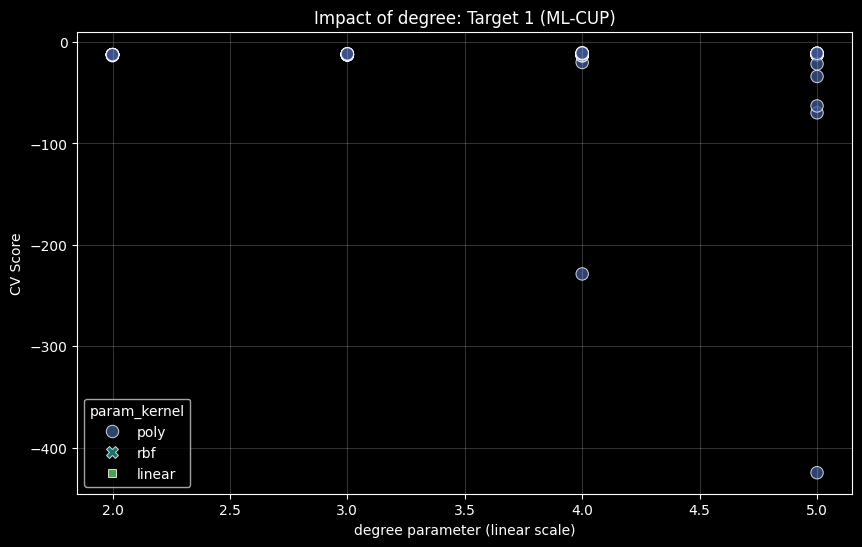

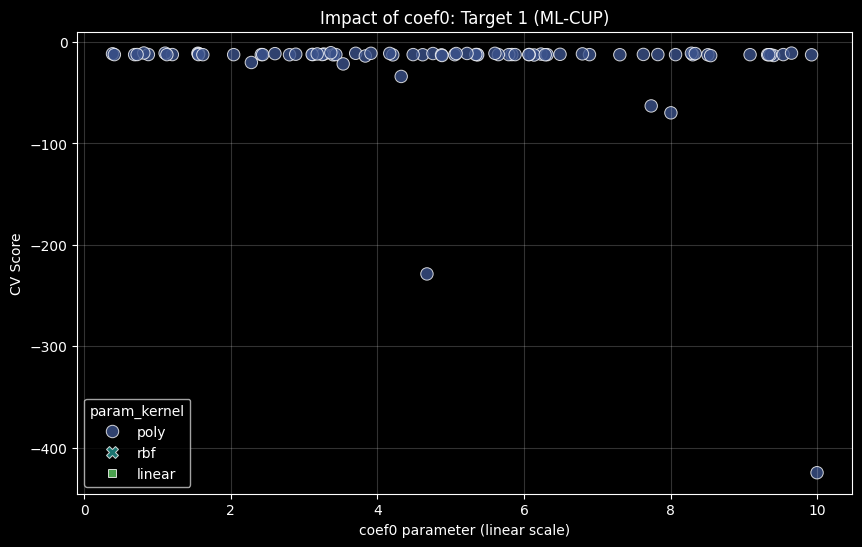

   -> All plots saved in ./svm_saved_models\regression\PCA\RandomSearch\SVR_20251228_235335
Processing Target 2...
   -> CSV saved: ./svm_saved_models\regression\PCA\RandomSearch\SVR_20251228_235335\rs_results_target_2.csv


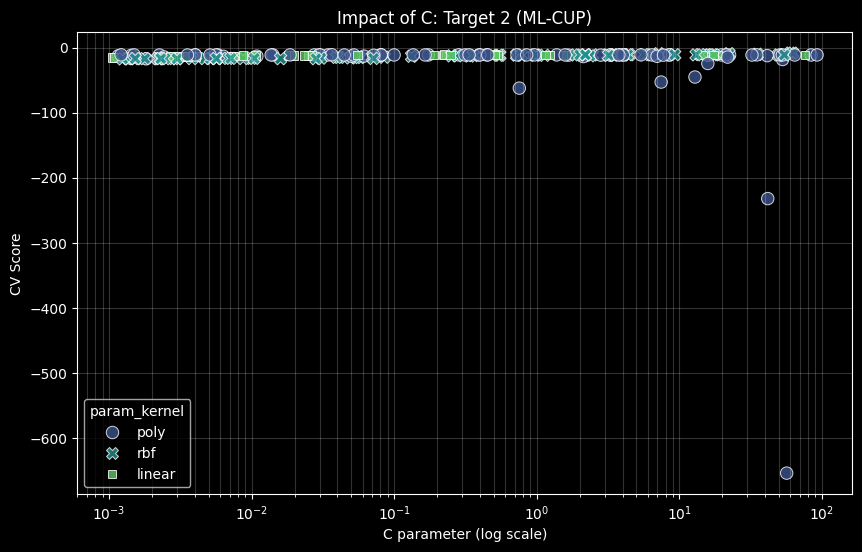

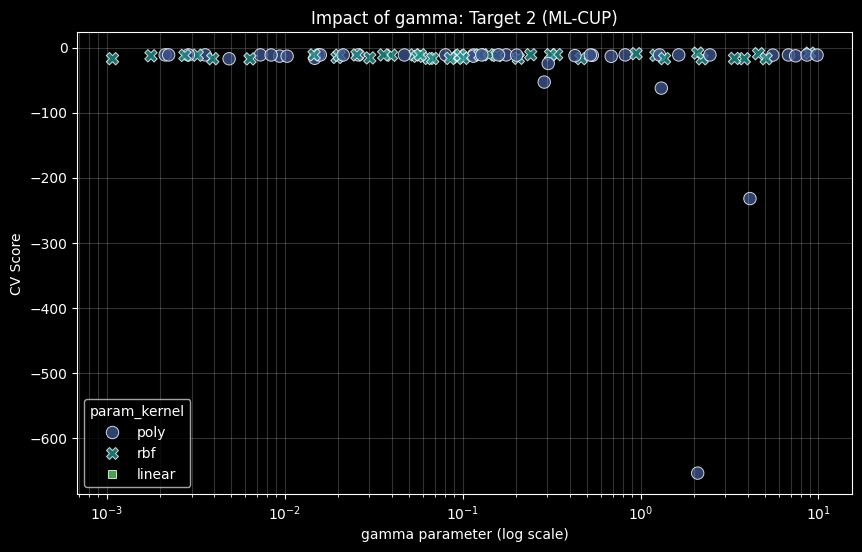

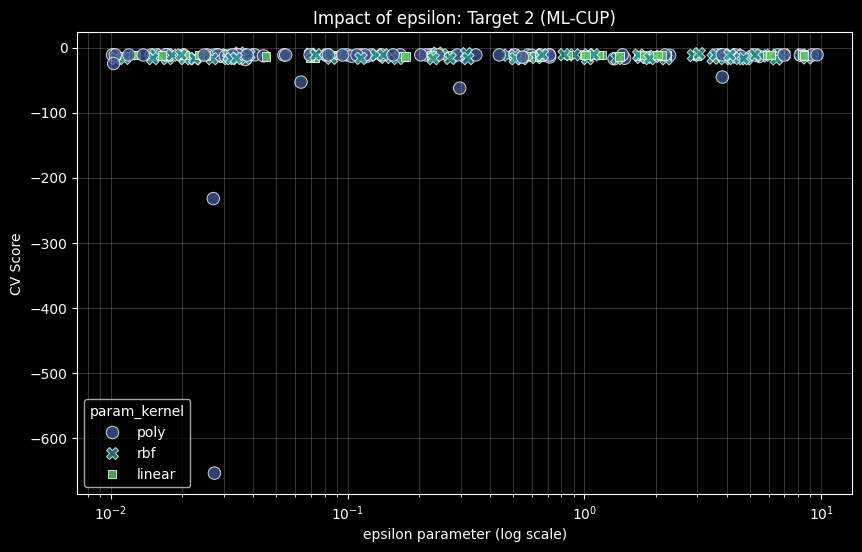

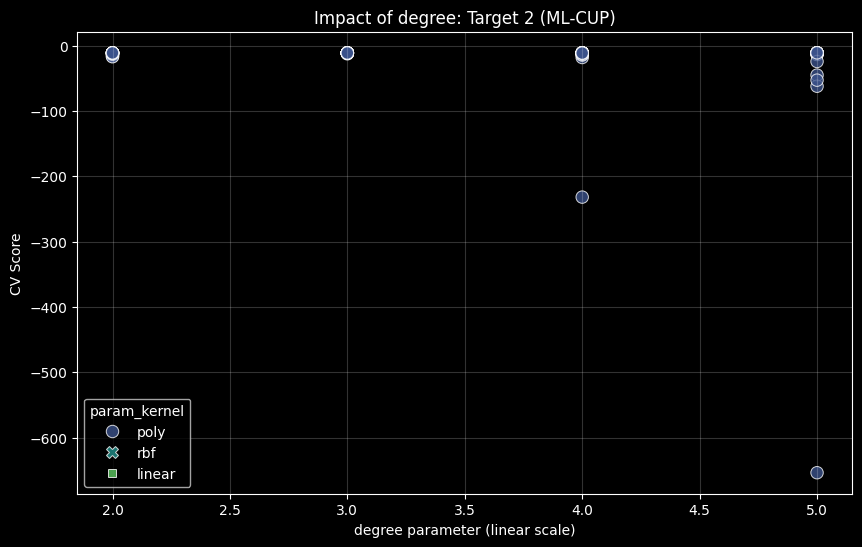

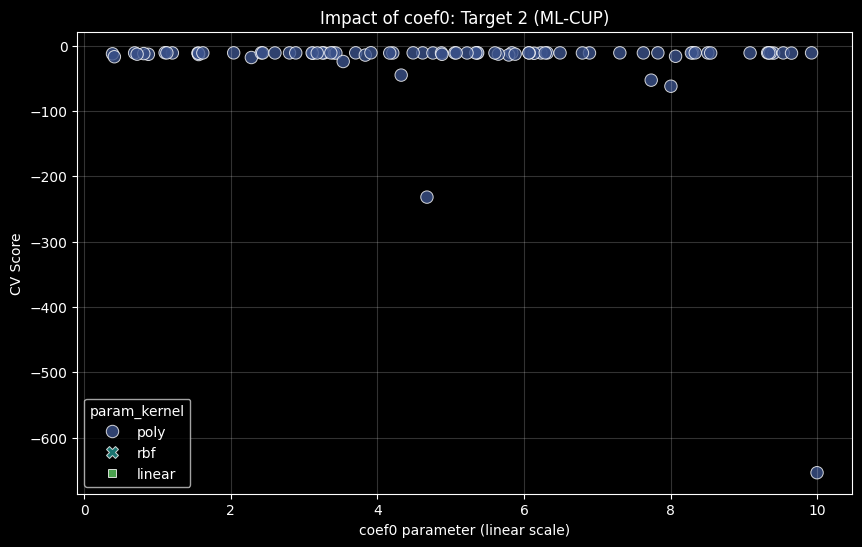

   -> All plots saved in ./svm_saved_models\regression\PCA\RandomSearch\SVR_20251228_235335
Processing Target 3...
   -> CSV saved: ./svm_saved_models\regression\PCA\RandomSearch\SVR_20251228_235335\rs_results_target_3.csv


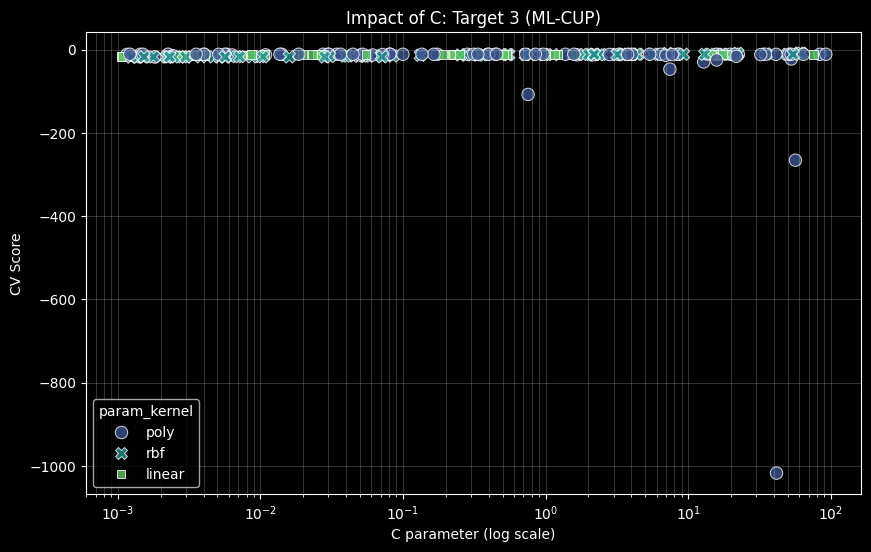

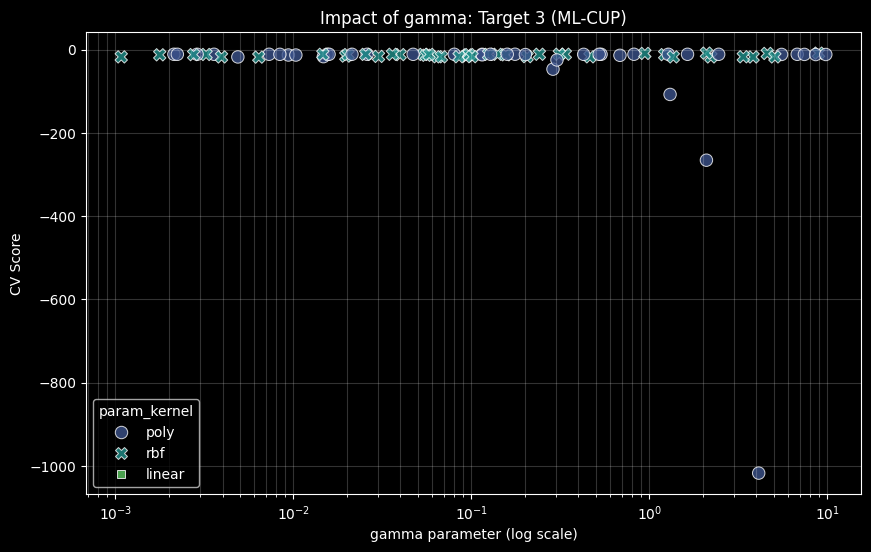

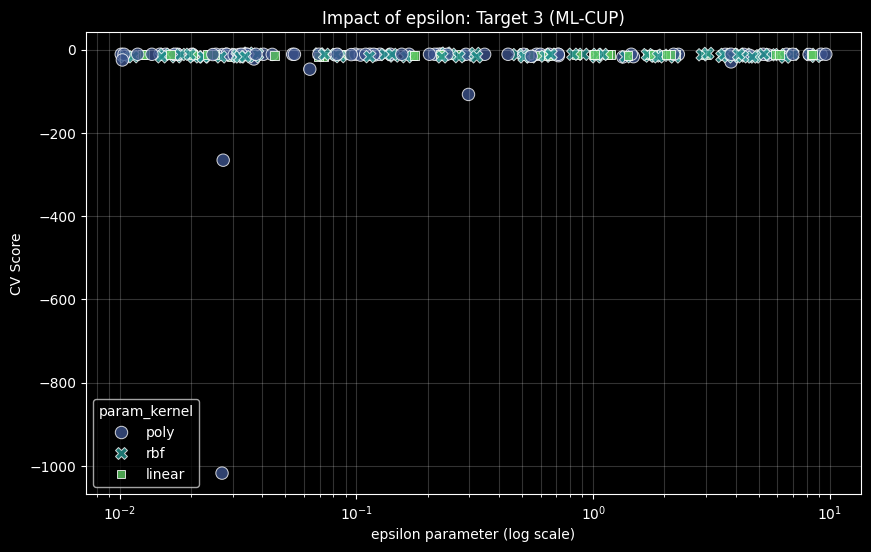

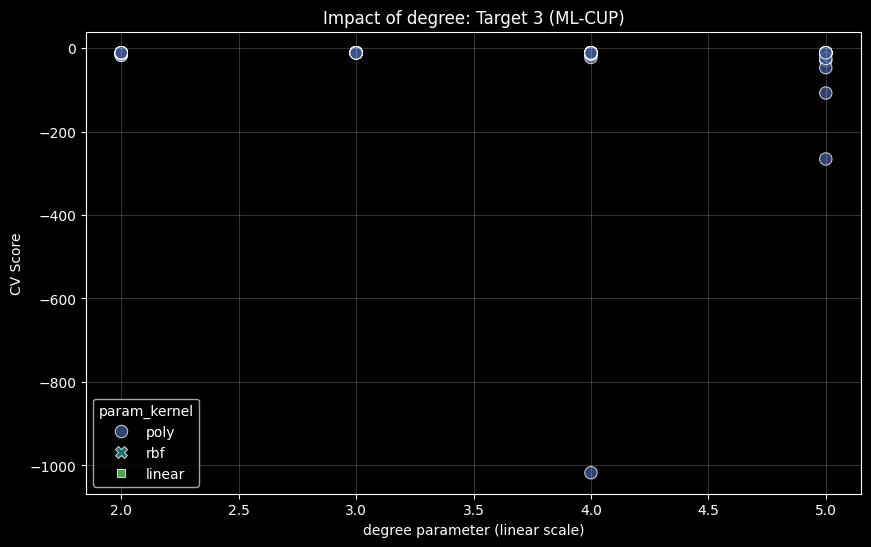

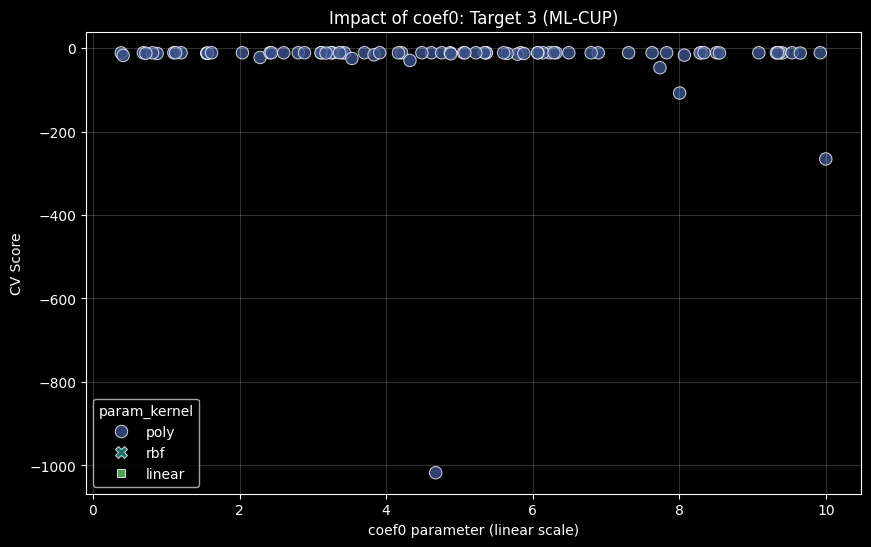

   -> All plots saved in ./svm_saved_models\regression\PCA\RandomSearch\SVR_20251228_235335


In [16]:
# 4.5 Comprehensive Analysis and Saving of Random Search Results

if not use_optuna:
    print("\n💾 Saving Random Search Results & Plots...")
    
    # CSV and Plotting Helper Function
    def save_rs_analysis(cv_results, filename_prefix, title_suffix):
        # 1. Convert to DataFrame
        df_res = pd.DataFrame(cv_results)
        
        # 2. Save CSV
        csv_path = os.path.join(run_dir, f"{filename_prefix}.csv")
        df_res.to_csv(csv_path, index=False)
        print(f"   -> CSV saved: {csv_path}")
        
        # 3. Plotting
        params_of_interest = ['C', 'gamma', 'epsilon', 'degree', 'coef0']
        
        for param_name in params_of_interest:
            col_name = f"param_{param_name}"
            
            # Skip if parameter not in results
            if col_name not in df_res.columns or df_res[col_name].isna().all():
                continue
            
            # Prepare DataFrame for plotting
            df_plot = df_res.copy()
            df_plot[col_name] = pd.to_numeric(df_plot[col_name], errors='coerce')
            
            # Skip if all values are NaN after conversion
            if df_plot[col_name].isna().all():
                continue

            plt.figure(figsize=(10, 6))
            try:
                # Scatterplot: Parameter vs Score
                sns.scatterplot(
                    data=df_plot, 
                    x=col_name, 
                    y='mean_test_score', 
                    hue='param_kernel', 
                    style='param_kernel',
                    s=80, alpha=0.8, palette='viridis'
                )
                
                plt.title(f"Impact of {param_name}: {title_suffix}")
                plt.ylabel("CV Score")
                plt.grid(True, which="both", ls="-", alpha=0.2)
                
                # Log scale for certain parameters
                if param_name in ['C', 'gamma', 'epsilon']:
                    plt.xscale('log')
                    plt.xlabel(f"{param_name} parameter (log scale)")
                else:
                    plt.xlabel(f"{param_name} parameter (linear scale)")
                
                # Save Plot
                plot_filename = f"{filename_prefix}_scatter_{param_name}.png"
                plot_path = os.path.join(run_dir, plot_filename)
                plt.savefig(plot_path)
                plt.show()
                plt.close()
                
            except Exception as e:
                print(f"   ⚠️ Plotting failed for {param_name}: {e}")
        
        print(f"   -> All plots saved in {run_dir}")

    # --- EXECUTION ---
    if is_regression_task:
        # Multi-Output: final_model contains N estimators
        for i, estimator in enumerate(final_model.estimators_):
            print(f"Processing Target {i}...")
            save_rs_analysis(
                estimator.cv_results_, 
                filename_prefix=f"rs_results_target_{i}",
                title_suffix=f"Target {i} (ML-CUP)"
            )
    else:
        # Single-Output: final_model is directly the RandomizedSearchCV
        print("Processing Single Target...")
        save_rs_analysis(
            final_model.cv_results_, 
            filename_prefix="rs_results_monk",
            title_suffix="MONK-1 Classification"
        )

In [ ]:
# 4.6 Print Best Parameters / Estimators
if not use_optuna:
    if is_regression_task:
        # Print estimators for each output if mlc25
        print(final_model.estimators_)
    else:
        print(final_model.best_params_)
        

In [ ]:
# 4.7 Final Model Reconstruction from Best Estimator
if not use_optuna:
    # --- 4.7.1 Helper Function to Create Wrapper from Estimator ---
    def create_model_from_estimator(best_estimator):
        """
        Extracts parameters from the best_estimator and creates an instance
        of the following custom wrapper (SVCModel or SVRModel).
        """
        # 1. Get parameters from the fitted model
        params = best_estimator.get_params()
        
        # 2. Determine the type and instantiate the correct wrapper
        if isinstance(best_estimator, SVC):
            return SVCModel(**params), 'svc'
        elif isinstance(best_estimator, SVR):
            return SVRModel(**params), 'svr'
        else:
            raise TypeError(f"Type unsupported for reconstruction: {type(best_estimator)}")

In [ ]:
if not use_optuna:
    # --- 4.7.2 Reconstruction Logic ---

    final_models_list = []  # List to hold final model wrappers
    is_multi_output = False # Flag to indicate multi-output scenario

    # MLC25 case: check if final_model has 'estimators_' attribute typical of MultiOutput wrapper
    if hasattr(final_model, 'estimators_'):
        print(f"Detected Multi-Output System ({len(final_model.estimators_)} targets).")
        is_multi_output = True
        
        # Iterate over each RandomizedSearchCV contained in the MultiOutput
        for i, search_obj in enumerate(final_model.estimators_):
            # Extract the winner for this specific target
            best_est = search_obj.best_estimator_
            
            # Create wrapper
            wrapper, m_type = create_model_from_estimator(best_est)
            final_models_list.append(wrapper)
            
            print(f"Target {i}: Configured {m_type.upper()} with C={wrapper.model.C:.4f}, gamma={wrapper.model.gamma}, epsilon={getattr(wrapper.model, 'epsilon', 'N/A')}")

    # MONK1 case: Single Output
    else:
        print("Detected Single-Output System.")
        # final_model is directly the RandomizedSearchCV
        best_est = final_model.best_estimator_
        best_params = best_est.get_params()

        best_params['probability'] = True  
        
        wrapper, m_type = create_model_from_estimator(best_est)
        final_models_list.append(wrapper)
        
        print(f"Configured {m_type.upper()} with C={wrapper.model.C:.4f}, gamma={wrapper.model.gamma}")

In [ ]:
# === 5. OPTUNA HYPERPARAMETER OPTIMIZATION ===

# 5.1 Optuna Optimization Logic
if use_optuna:
    import optuna
    import warnings
    from sklearn.svm import SVR, SVC
    from sklearn.model_selection import cross_val_score
    from optuna.samplers import TPESampler
    

    # List to hold final model wrappers
    final_models_list = [] 
    best_cv_scores = [] 
    N_TRIALS = 200

    print(f"🚀 Starting Optuna Optimization ({N_TRIALS} trials)...")

    # --- ML-CUP ---
    if is_regression_task:
        print(">>> Optimizing Multi-Output SVR (One model per target)...")
        
        # Loop over each target for multi-output regression
        for i in range(y_train.shape[1]):
            print(f"\n--- Optimizing Target {i} ---")
            y_current = y_train[:, i]
            
            def objective_svr(trial):
                # Kernel choice
                kernel_choice = trial.suggest_categorical('kernel', ['rbf','poly','linear'])

                # Conditional parameters
                gamma_param = 'scale'  # Default for linear kernel
                degree_param = 3
                coef0_param = 0.0

                if kernel_choice == 'poly':
                    gamma_param = trial.suggest_float('gamma', 1e-3, 1e1, log=True)
                    degree_param = trial.suggest_int('degree', 2, 5)
                    coef0_param = trial.suggest_float('coef0', 0.0, 10.0)
                elif kernel_choice == 'rbf':
                    gamma_param = trial.suggest_float('gamma', 1e-3, 1e1, log=True)

                # 1. Search Space Definition
                param = {
                    'kernel': kernel_choice,
                    'C': trial.suggest_float('C', 1e-3, 1e2, log=True),       
                    'epsilon': trial.suggest_float('epsilon', 1e-2, 1e1, log=True), 
                    'gamma': gamma_param,
                    'degree': degree_param,
                    'coef0': coef0_param
                }
                
                # 2. Model Instantiation
                model = SVR(**param, cache_size=1000, max_iter=100000)
                
                # 3. Validation  
                scores = cross_val_score(model, X_train, y_current, cv=5, scoring=mee_scorer, n_jobs=-1)
                return scores.mean() 

            # --- OPTUNA STUDY EXECUTION ---
            study = optuna.create_study(direction="maximize")
            study.optimize(objective_svr, n_trials=N_TRIALS, show_progress_bar=False)
            
            # --- SAVE CSV ---
            # Save trials to CSV
            try:
                csv_filename = f"svr_target_{i}_trials.csv"
                csv_path = os.path.join(run_dir, csv_filename)
                
                df_results = study.trials_dataframe()
                df_results.to_csv(csv_path, index=False)
                print(f"   💾 CSV saved: {csv_path}")
            except Exception as e:
                print(f"⚠️ Could not generate plots for target {i}: {e}")

            best_cv_score = abs(study.best_value)
            best_cv_scores.append(best_cv_score)

            print(f"✅ Best Params T{i}: {study.best_params}")
            
            # --- WRAPPER CREATION ---
            best_wrapper = SVRModel(**study.best_params, cache_size=1000, max_iter=100000)
            best_wrapper.fit(X_train, y_current) 
            
            final_models_list.append(best_wrapper)
            is_multi_output = True

    # --- MONK1 ---
    else:
        print(">>> Optimizing SVC (Single Output)...")
        
        def objective_svc(trial):
            kernel_choice = trial.suggest_categorical('kernel', ['linear', 'rbf', 'poly'])

            degree_param = 3
            coef0_param = 0.0
            gamma_param = 'scale'

            if kernel_choice == 'poly':
                degree_param = trial.suggest_int('degree', 2, 5)
                coef0_param = trial.suggest_float('coef0', 0.0, 10.0)
            elif kernel_choice != 'linear':
                gamma_param = trial.suggest_float('gamma', 1e-3, 1e1, log=True)

            param = {
                'kernel': kernel_choice,
                'C': trial.suggest_float('C', 1e-3, 1e2, log=True),
            }

            if kernel_choice != 'linear':
                param['gamma'] = gamma_param
            if kernel_choice == 'poly':
                param['degree'] = degree_param
                param['coef0'] = coef0_param
                
            model = SVC(**param, cache_size=1000)
            scores = cross_val_score(model, X_train, y_train.ravel(), cv=5, scoring='accuracy', n_jobs=-1)
            return scores.mean()

        study = optuna.create_study(direction="maximize", sampler=TPESampler(seed))
        study.optimize(objective_svc, n_trials=N_TRIALS, show_progress_bar=True)
        
        # 1. CSV
        try:
            csv_path = os.path.join(run_dir, "optuna_results_monk.csv")
            df_results = study.trials_dataframe()
            df_results.to_csv(csv_path, index=False)
            print(f"   💾 CSV saved: {csv_path}")
        except Exception as e:
            print(f"⚠️ Could not generate plots: {e}")

        best_cv_scores.append(study.best_value)

        print(f"✅ Best Params: {study.best_params}")
        
        # --- WRAPPER CREATION---
        best_wrapper = SVCModel(**study.best_params, cache_size=1000, probability=True)
        best_wrapper.fit(X_train, y_train.ravel())
        
        final_models_list.append(best_wrapper)
        is_multi_output = False  # Flag for single-output
        
    print(f"\n🎉 Optimization Complete. Models ready in 'final_models_list': {len(final_models_list)}")

    

In [ ]:
# 5.2 Print Final Models Summary

if use_optuna:
    # Print final models summary
    if is_multi_output:
        for i, model in enumerate(final_models_list):
            print(f"Target {i}: Model with params: {model.model.get_params()}")
    else:
        print(f"Single Target Model with params: {final_models_list[0].model.get_params()}")

In [ ]:
# === 6. FINAL FITTING ===

print("\n--- Starting Final Refitting of Models ---")

if is_multi_output:
    for i, wrapper in enumerate(final_models_list):
        print(f"Fitting Target {i}...")
        # Note: y_train[:, i] takes only the i-th column
        wrapper.fit(X_train, y_train[:, i]) 
        
else:
    print("Fitting Single Model...")
    final_models_list[0].fit(X_train, y_train.ravel())

print("Refitting done.")

In [ ]:
# === 7. PREDICTION & EVALUATION ===

# 7.1 Training Evaluation (New: Check for Overfitting)
print("\n--- 7.1 Evaluation on TRAINING Set ---")

if is_multi_output:
    # Multi-Output Case (es. ML-CUP): Predict on Training Data
    train_column_preds = []
    for wrapper in final_models_list:
        # Prevediamo su X_train
        pred_tr = wrapper.predict(X_train)
        train_column_preds.append(pred_tr)
    
    # Combine columns
    y_train_pred = np.column_stack(train_column_preds)
    y_train_eval = y_train 

else:
    # Single Output Case (es. MONK): Predict on Training Data
    y_train_pred = final_models_list[0].predict(X_train)
    y_train_eval = y_train.ravel()

# Calculate Training Metric
if is_regression_task:
    final_train_metric = mean_euclidean_error(y_train_eval, y_train_pred)
    print(f"📉 Final Training {metric_name}: {final_train_metric:.5f}")
else:
    # Per classificazione mostriamo sia Accuracy che Errore
    train_acc = accuracy_score(y_train_eval, y_train_pred) * 100.0
    final_train_metric = train_acc
    print(f"📉 Final Training Accuracy: {train_acc:.2f}% (Error: {100-train_acc:.2f}%)")


# 7.2 Generation of Predictions on TEST Set
print("\n--- 7.2 Generating Predictions on TEST Set ---")

if is_multi_output:
    # Multi-Output Case: Iterate over the list of models
    column_preds = []
    for wrapper in final_models_list:
        pred = wrapper.predict(X_test)
        column_preds.append(pred)
    
    # Combine columns: (N_samples, N_targets)
    y_test_pred = np.column_stack(column_preds)
    y_test_eval = y_test 
    
else:
    # Single Output Case: Directly use the single model
    y_test_pred = final_models_list[0].predict(X_test)
    
    # Flatten y_test for comparison
    y_test_eval = y_test.ravel()

print(f"Predictions generated. Shape: {y_test_pred.shape}")


# 7.3 Calculating Final Test Metrics
print("\n--- 7.3 Calculating Final Metrics ---")

if is_regression_task:
    # Calculate MEE for Regression
    final_test_metric = mean_euclidean_error(y_test_eval, y_test_pred)
    print(f"🏆 Final Test {metric_name}: {final_test_metric:.5f}")
else:
    # Calculate Accuracy for Classification
    final_test_metric = accuracy_score(y_test_eval, y_test_pred) * 100.0
    print(f"🏆 Final Test Accuracy: {final_test_metric:.2f}% (Error: {100-final_test_metric:.2f}%)")


In [ ]:
# 7.4 Baseline Comparison (Dummy Regressor for Regression Tasks)
from sklearn.dummy import DummyRegressor
from sklearn.metrics import make_scorer

if is_regression_task:
    # 1. Define dummy model
    # strategy='mean' predicts always the mean of the training set for each target
    dummy_regr = DummyRegressor(strategy="mean")

    # 2. Training (just computes means, it's instantaneous)
    print("\n--- Training Baseline (Dummy Regressor) ---")
    dummy_regr.fit(X_train, y_train)

    # 3. Prediction
    y_pred_dummy = dummy_regr.predict(X_test)

    # 4. Baseline MEE Calculation
    mee_baseline = mean_euclidean_error(y_test, y_pred_dummy)

    print(f"Baseline MEE (Mean Strategy): {mee_baseline:.4f}")
    print(f"Best SVR model MEE:          {final_test_metric:.4f}") 

    # 5. Comparison
    if final_test_metric < mee_baseline:
        print("SUCCESS: the model outperforms the baseline!")
        improvement = mee_baseline - final_test_metric
        print(f"   Improvement: {improvement:.4f} MEE points")
    else:
        print("FAIL: the model is worse than the baseline.")

In [ ]:
# 7.5 Baseline Comparison (Dummy Classifier for Classification Tasks)
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

if not is_regression_task:
    print("\n--- Training Baseline (Dummy Classifier) ---")
    
    # 1. Define dummy model
    # strategy='most_frequent' always predicts the most frequent class in the training set
    dummy_clf = DummyClassifier(strategy="most_frequent")
    
    # 2. Training 
    dummy_clf.fit(X_train, y_train.ravel())
    
    # 3. Prediction
    y_pred_dummy = dummy_clf.predict(X_test)
    
    # 4. Baseline Accuracy Calculation
    acc_baseline = accuracy_score(y_test.ravel(), y_pred_dummy) * 100.0
    
    print(f"Baseline Accuracy (Most Frequent): {acc_baseline:.2f}%")
    print(f"Best SVC model Accuracy:          {final_test_metric:.2f}%") 
    
    # 5. Comparison
    if final_test_metric > acc_baseline:
        print("SUCCESS: the model outperforms the baseline!")
        print(f"   Improvement: +{final_test_metric - acc_baseline:.2f}%")
    else:
        print("FAIL: the model is worse than the baseline.")

In [ ]:
# 7.6 Learning Curve Visualization
import matplotlib.pyplot as plt

print("\n--- Generating Learning Curves ---")

if is_regression_task:
    # Use MEE as scoring metric for regression
    score_metric = mee_scorer 
else:
    # For classification use standard accuracy
    score_metric = 'accuracy'

# Loop over models (1 for Monk, 4 for ML-CUP)
for i, wrapper in enumerate(final_models_list):
    print(f"\nGenerating curve for model {i}...")
    
    # Select appropriate target data
    if is_regression_task:
        # Choose the specific i-th column for ML-CUP
        current_y = y_train[:, i]
        title = f"Target {i} Learning Curve"
    else:
        # In case of MONK use ravel() to flatten the array
        current_y = y_train.ravel()
        title = "Monk-1 Classification Learning Curve"
        
    wrapper.plot_learning_curve(X_train, current_y, cv=5, scoring=score_metric)

print("\n--- Done ---")

In [ ]:
# === 8. SYSTEM SAVING (Final Update) ===
import os
import json
import joblib

# 8.1 Saving Function Definition
def save_model_system(models_list, scaler, pca_obj, dataset_name, is_regression, optimization_method, 
                      final_train_score, final_test_score, cv_scores_list, seed,
                      target_dir):  
    """
    Saves the trained models, scaler, and updates the registry JSON file.
    Parameters:
    - models_list: List of trained model wrappers (SVCModel or SVRModel).
    - scaler: The fitted scaler object (e.g., StandardScaler).
    - dataset_name: Name of the dataset (e.g., 'mlc25', 'monk1').
    - is_regression: Boolean indicating if the task is regression.
    - optimization_method: String indicating the optimization method used ('Optuna' or 'RandomSearch').
    - final_train_score: Final training score (float).
    - final_test_score: Final test score (float).
    - cv_scores_list: List of cross-validation scores for each target/model.
    - seed: Random seed used for reproducibility.
    - target_dir: Directory where to save the models and registry.
    """
    # Extract run name from target_dir
    run_name = os.path.basename(target_dir)
    
    # Define registry file path
    method_folder = os.path.dirname(target_dir)
    registry_file = os.path.join(method_folder, f"registry.json")

    # 1. Load Registry
    registry = {}
    if os.path.exists(registry_file):
        try:
            with open(registry_file, 'r') as f:
                registry = json.load(f)
        except json.JSONDecodeError:
            print("Warning: Registry corrupted. Starting fresh.")
    
    # 2. Save Scaler 
    scaler_path = os.path.join(target_dir, "scaler.pkl")
    joblib.dump(scaler, scaler_path)
    print(f"📁 Scaler saved to: {scaler_path}")

    # Save PCA if exists
    if pca_obj is not None:
        pca_path = os.path.join(target_dir, "pca_model.pkl")
        joblib.dump(pca_obj, pca_path)
        print(f"📁 PCA model saved to: {pca_path}")

    # 3. Construct JSON Entry
    json_entry = {
        "type": "MultiOutput SVR" if is_regression else "SVC",
        "method": optimization_method,
        "seed": seed,
        "location": target_dir,
        "pca_active": pca_obj is not None,
        "train_loss": round(final_train_score, 4),
        "global_test_score": round(final_test_score, 4),
        "metric_name": "MEE" if is_regression else "Accuracy",
        "targets": {} 
    }

    # 4. Save Models
    if is_regression:
        for i, wrapper in enumerate(models_list):
            filename = f"target_{i}.pkl"
            wrapper.save_pkl(os.path.join(target_dir, filename))
            
            json_entry["targets"][f"target_{i}"] = {
                "cv_score": round(cv_scores_list[i], 4),
                "params": wrapper.get_params_clean()
            }
    else:
        wrapper = models_list[0]
        wrapper.save_pkl(os.path.join(target_dir, "classifier_model.pkl"))
        json_entry["targets"]["classifier"] = {
            "cv_score": round(cv_scores_list[0], 4),
            "params": wrapper.get_params_clean()
        }

    # 5. Write Registry
    registry[run_name] = json_entry
    with open(registry_file, 'w') as f:
        json.dump(registry, f, indent=4)
        
    print(f"📝 Registry updated: {registry_file}")
    print(f"✅ System Saved in: {target_dir}")



In [ ]:
# 8.2 Saving Criteria and Execution

current_method = "Optuna" if use_optuna else "RandomSearch"

# Define tolerances
REGRESSION_TOLERANCE = 0.3
CLASSIFICATION_TOLERANCE = 10.0
ABSOLUTE_MEE_THRESHOLD = 20.0
UNDERFITTING_MEE_THRESHOLD = 25.0
should_save = False
reason = ""

# Check overfitting criteria
if is_regression_task:
    delta = final_test_metric - final_train_metric
    ratio = delta / (final_train_metric + 1e-9)  # Avoid division by zero

    print(f"\n--- Save Criteria Check for Regression ---")
    print(f"Train MEE: {final_train_metric:.4f}")
    print(f"Test MEE: {final_test_metric:.4f}")
    print(f"Delta: {delta:.4f}, Ratio: +{ratio*100:.2f}%")

    if final_test_metric < ABSOLUTE_MEE_THRESHOLD:
        reason = f"✅ Saving: Test MEE {final_test_metric:.4f} < {ABSOLUTE_MEE_THRESHOLD}"
        should_save = True
    elif ratio > REGRESSION_TOLERANCE:
        reason = f"❌ Not saving: Overfitting detected (Ratio +{ratio*100:.2f}% > {REGRESSION_TOLERANCE*100:.2f}%)"
        should_save = False
    elif final_train_metric > UNDERFITTING_MEE_THRESHOLD:
        reason = f"❌ Not saving: Underfitting detected (Train MEE {final_train_metric:.4f} > {UNDERFITTING_MEE_THRESHOLD})"
        should_save = False
    else:
        reason = "✅ Saving: No significant overfitting or underfitting detected."
        should_save = True

else:
    delta = final_train_metric - final_test_metric
    
    print(f"\n--- Save Criteria Check for Classification ---")
    print(f"Train Accuracy: {final_train_metric:.2f}%")
    print(f"Test Accuracy: {final_test_metric:.2f}%")
    print(f"Gap: {delta:.2f}%")

    if final_test_metric <= 55.0:
        reason = f"❌ Not saving: Test accuracy too low ({final_test_metric:.2f}% <= 55.0%)"
        should_save = False
    elif delta > CLASSIFICATION_TOLERANCE:
        reason = f"❌ Not saving: Overfitting detected (Gap {delta:.2f}% > {CLASSIFICATION_TOLERANCE:.2f}%)"
        should_save = False
    else:
        reason = "✅ Saving: No significant overfitting detected."
        should_save = True 

# Conditional Save Execution
if should_save:
    print("Model meets criteria for saving.")
    save_model_system(
        models_list=final_models_list, 
        scaler=scaler,
        pca_obj=pca_model,
        dataset_name=dataset_name, 
        is_regression=is_regression_task,
        optimization_method=current_method,
        final_train_score=final_train_metric,
        final_test_score=final_test_metric,
        cv_scores_list=best_cv_scores,
        seed=seed,
        target_dir=run_dir  
    )
else: 
    print("Model discarded due to overfitting criteria.")

In [ ]:
# === 9. VISUALIZATIONS (INFERENCE ANALYSIS) ===
# This section generates plots using methods integrated in the wrappers.

print("\n--- Generating Analysis Plots ---")

if is_regression_task:
    # --- ML-CUP (Regression) ---
    # Generate one scatter plot for each target (4 total)
    
    for i, wrapper in enumerate(final_models_list):
        print(f"Plotting Target {i}...")
        
        # Get the correct column of y_test for this target
        y_test_target = y_test[:, i]
        
        # Nota: Non serve passare y_pred, lo calcola lui internamente da X_test
        wrapper.plot_regression_analysis(X_test, y_test_target, title_suffix=f"Target {i}")

else:
    # --- MONK (Classification) ---
    # Generate Confusion Matrix and ROC Curve
    print("Plotting Classification Analysis...")
    
    wrapper = final_models_list[0]
    
    wrapper.plot_classification_analysis(X_test, y_test.ravel())

print("Visualizations complete.")

In [ ]:
# === 10. OPTUNA VISUALIZATION (FROM CSV) ===

if use_optuna:
    print("\n--- Generating Optuna Plots from Saved CSVs ---")
    
    # Importiamo qui le librerie di visualizzazione (Plotly required)
    from utils.optuna import import_csv
    from optuna.visualization import plot_optimization_history, plot_param_importances
    
    def show_optuna_plots(study, title_prefix):
        print(f"\n📊 Visualizing: {title_prefix}")
        
        # History
        fig_hist = plot_optimization_history(study)
        fig_hist.update_layout(title=f"{title_prefix} - Optimization History")
        fig_hist.show()
        
        # Importance
        try:
            fig_imp = plot_param_importances(study)
            fig_imp.update_layout(title=f"{title_prefix} - Hyperparameter Importance")
            fig_imp.show()
        except Exception as e:
            print(f"   ⚠️ Importance plot skipped: {e}")

    # --- EXECUTION ---
    if is_regression_task:
        # Loop over each target for ML-CUP
        for i in range(y_train.shape[1]):
            csv_name = f"svr_target_{i}_trials.csv"
            csv_path = os.path.join(run_dir, csv_name)
            
            if os.path.exists(csv_path):
                # Import study from CSV with maximize due to negative MEE
                study = import_csv(csv_path, direction="maximize")
                show_optuna_plots(study, title_prefix=f"Target {i}")
            else:
                print(f"❌ CSV not found: {csv_path}")

    else:
        # Monk1 case
        csv_name = "optuna_results_monk.csv"
        csv_path = os.path.join(run_dir, csv_name)
        
        if os.path.exists(csv_path):
            study = import_csv(csv_path, direction="maximize")
            show_optuna_plots(study, title_prefix="MONK-1 Classification")
        else:
            print(f"❌ CSV not found: {csv_path}")